### Fig. 1 and Fig. 2: Pathways and transit times
#### Due to random draw of 200 trajectories, panels in Fig. 1a and Fig. 2a looks different for each time generated

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import os 
import warnings
import random
warnings.filterwarnings("ignore")

#os.environ["OMP_NUM_THREADS"] = "8"

dir_trajs = 'YOUR_TRAJ_DATA_PATH'
dir_quant = 'YOUR_DATA_PATH'
 

In [3]:
# Trajectories of 2017 seeding (for figure 1a and figure 2a)
column_names = ['id', 'x', 'y', 'z', 'vt', 'time', 'wall', 'temp', 'salt', 'dens']
cols_needed = ['id','x','y','time']
df = pd.read_csv(dir_trajs+'traj_seed_2017.csv', dtype={'id': int}, usecols=cols_needed) 

# January seeding is at time 0
df_init_jan = df[df['time'] <= 0]          # initial rows for Jan-seeded particles
id_jan = df_init_jan['id']
df_jan = df[df['id'].isin(id_jan)]         # full trajectories for those particles

In [12]:
# Random draw of 200 trajectories
id_max=max(df_init_jan['id'].values)
sel_ids = random.sample(range(0, id_max + 1), 200)  

In [13]:
# Load saved volume weighted particle probability densities
# Gridded at 1/4 degree lon, lat
p=np.load(dir_quant + 'prob_dens_VTw_1990-2017.npz') #saved in 'prob_dens_comp.py'
xedges = p['xedges']
yedges = p['yedges']
COUNTSvt = p['COUNTSvt']

In [14]:
# Prep. for plotting - colormap and binning

# Centre of bins 
xcenters = 0.5 * (xedges[:-1] + xedges[1:])
ycenters = 0.5 * (yedges[:-1] + yedges[1:])

# Define the meshgrid for plotting
X, Y = np.meshgrid(xcenters, ycenters) 

# Set zeros to nan
COUNTSnanVT = COUNTSvt
COUNTSnanVT[COUNTSnanVT == 0] = np.nan

# Normalizing counts
COUNTSmeanVT = 100*( np.nansum(COUNTSnanVT,axis=2) / np.nansum(COUNTSnanVT[:]) )
COUNTSmeanVT[COUNTSmeanVT == 0] = np.nan
print(np.nansum(COUNTSmeanVT[:]))

from matplotlib.colors import ListedColormap
import matplotlib as mpl
import random 

# Custom colormap 
mycmap4 = [(0.93,         0.95,       0.95   ),
         (0.86168397, 0.91280277, 0.94975779), #without white
         (0.71146482, 0.80127643, 0.8883045 ),
         (0.58998847, 0.67472511, 0.82199154),
         (0.56,       0.6,        0.79      ), 
         (0.54901961, 0.49036524, 0.72867359),
         (0.53788543, 0.30269896, 0.63844675),
         (0.515,      0.2,        0.55      ),
         (0.50943483, 0.08419839, 0.50302191),
         (0.7,        0.,         0.1      ),  
         (0.9       , 0.        , 0.        ), #next starts
         (1.        , 0.21176471, 0.        ),
         (1.        , 0.35686275, 0.        ),
         (1.        , 0.50196078, 0.        ),
         (1.        , 0.57254902, 0.        ),
         (1.        , 0.71372549, 0.        ),
         (1.        , 0.85882353, 0.        ),
         (1.        , 0.95      , 0.1        )]

custom_cmap4 = ListedColormap(mycmap4)

100.00000000000009


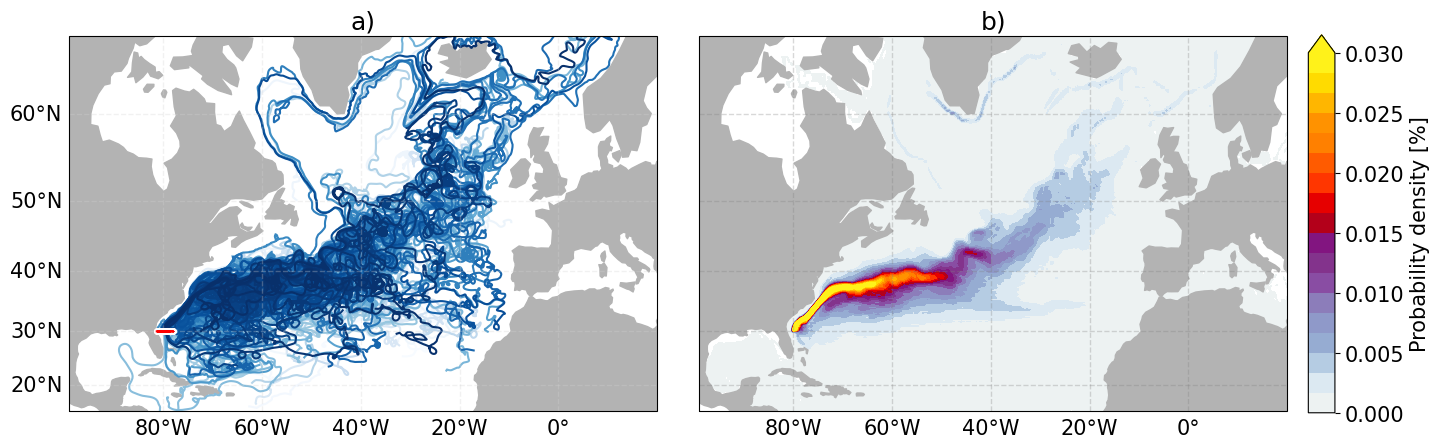

In [15]:
# Plotting Fig. 1
# a) Subset of 200 trajectories from 2017 seeding
# b) VT-weighted probability density (1/4 bins) 

from cartopy import crs
import cartopy.feature as cfeatures

data_proj = crs.PlateCarree( ) 
display_proj = crs.Mercator( )

c1 = plt.cm.Blues(np.linspace(0, 1, 200))
k=0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7),subplot_kw={'projection': display_proj})

# a) 200 trajectories 
ax1.set_extent([-99,20,15,67],crs=data_proj)
ax1.add_feature(cfeatures.LAND,edgecolor=(.3, .3, .3),color=(.7, .7, .7),zorder=2)
g1=ax1.gridlines( draw_labels = True, linewidth = 1, color = 'lightgrey',alpha = 0.3, linestyle = '--')  
g1.xlabels_bottom = True
g1.ylabels_right = False
g1.xlabels_top = False
#loop over particles 
for i, pid in enumerate(sel_ids):
    p = df_jan[df_jan['id'] == pid]
    ax1.plot(p['x'].values, p['y'].values, transform=data_proj, color=c1[i])
ax1.plot(df_init_jan['x'].values,df_init_jan['y'].values,transform=data_proj,marker = '.', color = 'white', markersize=7, zorder=10)
ax1.plot(df_init_jan['x'].values,df_init_jan['y'].values,transform=data_proj,marker = '.', color = 'red', markersize=0.2, zorder=12)
ax1.set_title('a)')

# b) Probability density
ax2.set_extent([-99,20,15,67],crs=data_proj)
ax2.add_feature(cfeatures.LAND,edgecolor=(.3, .3, .3),color=(.7, .7, .7),zorder=2)
g2=ax2.gridlines( draw_labels = True, linewidth = 1, color = 'grey',alpha = 0.3, linestyle = '--')  
g2.xlabels_bottom = True
g2.ylabels_left = False
g2.ylabels_right = False
g2.xlabels_top = False
ctrs = ax2.contourf(X, Y, COUNTSmeanVT.T, transform=data_proj, cmap=custom_cmap4, levels=np.linspace(0, 0.03, 19), extend='max')
ax2.set_title('b)')

ax1.set_position([0.05, 0.1, 0.42, 0.8])  
ax2.set_position([0.5, 0.1, 0.42, 0.8]) 

#cbar
cbar_ax = fig.add_axes([0.935, 0.23, 0.019, 0.54])
cbar = fig.colorbar(ctrs, cax=cbar_ax, orientation='vertical', ticks=[0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03])
cbar.set_label('Probability density [%]')

plt.rcParams.update({'font.size': 15})

In [ ]:
#################################

In [16]:
# Recirculation vs. throughput - vectorized (January 2017) 
latmax_particle = df_jan.groupby('id')['y'].max()  #Get max latitude per particle

# Categorize IDs based on max latitude
id_stg = latmax_particle[latmax_particle < 45].index.tolist()  #IDs staying in STG
id_spg = latmax_particle[latmax_particle >= 45].index.tolist()

In [17]:
# Upload saved data
df_spg = pd.read_csv(dir_quant+'vtSPG_an_1990-2017_data.csv') #(saved in part_quant_1990-2017.py)
df_stg = pd.read_csv(dir_quant+'vtSTG_an_1990-2017_data.csv') 

f=np.load(dir_quant+'histogram_1990-2017_data_100326.npz')    #(saved in part_quant_transit-time_45N.py)
bins_hist = f['bins']
counts_hist = f['counts']

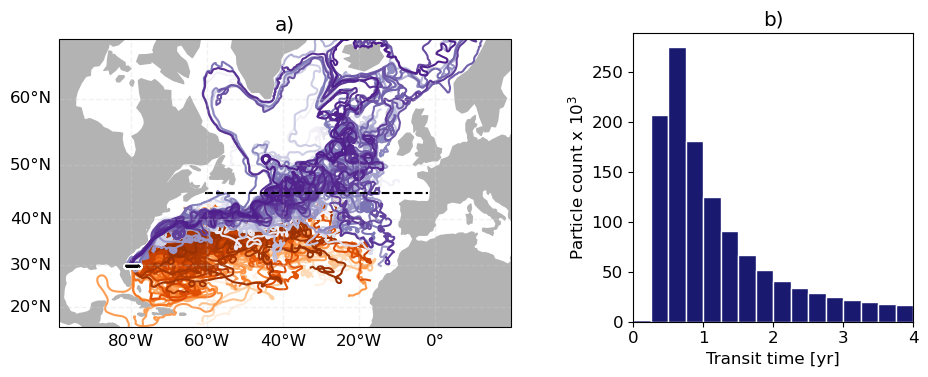

In [20]:
# Plotting Fig. 2
import matplotlib.gridspec as gridspec

c1 = plt.cm.Oranges(np.linspace(0, 1, 160)) 
c2 = plt.cm.Purples(np.linspace(0, 1, 70))  
col1 = c1[(len(c1) // 2)+15] 
col2 = c2[(len(c2) // 2)+15] 

k=0
j=0

fig = plt.figure(figsize=(14, 7))
gs = gridspec.GridSpec(1, 2, hspace=0.5, wspace=0.4)

# a) 200 trajectories sorted
ax_map = fig.add_subplot(gs[0, 0], projection = display_proj) 
ax_map.set_extent([-99,20,15,67],crs=data_proj)
ax_map.add_feature(cfeatures.LAND,edgecolor=(.3, .3, .3),color=(.7, .7, .7),zorder=2)
g1=ax_map.gridlines( draw_labels = True, linewidth = 1, color = 'lightgrey',alpha = 0.3, linestyle = '--')  
g1.ylabels_right = False
g1.xlabels_top = False
# loop over particles 
for pid in sel_ids:
    p = df_jan[df_jan['id'] == pid]
    if pid in id_stg:
        color = c1[k+5]  
        k = k+1
        ax_map.plot(p['x'].values, p['y'].values, transform=data_proj, color=color)
for pid in sel_ids:
    p = df_jan[df_jan['id'] == pid]
    if pid in id_spg:
        color = c2[j+5]    
        j = j+1
        ax_map.plot(p['x'].values, p['y'].values, transform=data_proj, color=color)
ax_map.plot(df_init_jan['x'].values,df_init_jan['y'].values,transform=data_proj,marker = '.', color = 'white', markersize=7, zorder=10)
ax_map.plot(df_init_jan['x'].values,df_init_jan['y'].values,transform=data_proj,marker = '.', color = 'black', markersize=0.2, zorder=12)
ax_map.plot(np.linspace(-60.7,-2,50),45*np.ones(50),transform=data_proj,linestyle='--',color = 'black')
ax_map.set_title('a)')

# b) Histogram
ax_hist = fig.add_subplot(gs[0, 1])
plt.hist(bins_hist[:-1], bins_hist, weights=counts_hist/1000, color='midnightblue',edgecolor='white')
plt.xlabel('Transit time [yr]')
plt.ylabel('Particle count x $10^3$')
ax_hist.set_xlim(0,4)
ax_hist.set_title('b)')

ax_hist.set_position([0.535, 0.2967976501534412, 0.2, 0.412]) 

plt.rcParams.update({'font.size': 12})